# LAB | Central Limit Theorem and Normality Tests


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot

# Set random seed for reproducibility
np.random.seed(42)

# Setting plot style
plt.style.use('seaborn-v0_8')

## Challenge 1: Basic Central Limit Theorem Demonstration

In this challenge, you'll explore the fundamental concept of the Central Limit Theorem
by generating samples from different distributions and observing how their sample means
approach a normal distribution as sample size increases.

# Instructions
Instructions:
1. We'll create a non-normal distribution (exponential distribution)
2. Draw samples of different sizes and calculate their means
3. Observe how the distribution of sample means approaches normal distribution
4. Complete the code below to create histograms for sample means


In [2]:
# Set parameters
population_size = 10000
sample_sizes = [1, 5, 30, 100]  # Increasing sample sizes
n_samples = 1000  # Number of samples to draw for each sample size

# Create a non-normal population (exponential distribution with lambda=0.5)
population = np.random.exponential(scale=2, size=population_size)

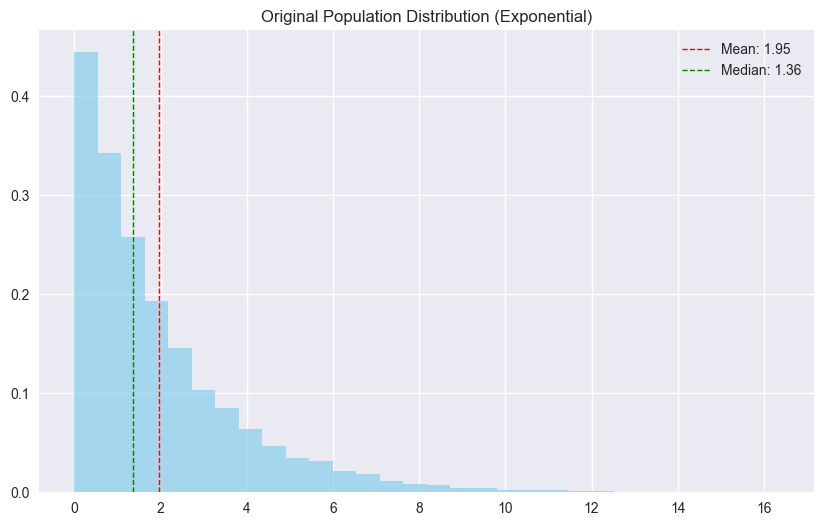

Population statistics:
Mean: 1.9550
Median: 1.3566
Variance: 3.7975
Skewness: 1.9190
Kurtosis: 5.1151



In [3]:
# Plot the original population distribution
plt.figure(figsize=(10, 6))
plt.hist(population, bins=30, alpha=0.7, color='skyblue', density=True)
plt.title('Original Population Distribution (Exponential)')
plt.axvline(np.mean(population), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(population):.2f}')
plt.axvline(np.median(population), color='green', linestyle='dashed', linewidth=1, label=f'Median: {np.median(population):.2f}')
plt.legend()
plt.show()

print(f"Population statistics:")
print(f"Mean: {np.mean(population):.4f}")
print(f"Median: {np.median(population):.4f}")
print(f"Variance: {np.var(population):.4f}")
print(f"Skewness: {stats.skew(population):.4f}")
print(f"Kurtosis: {stats.kurtosis(population):.4f}\n")

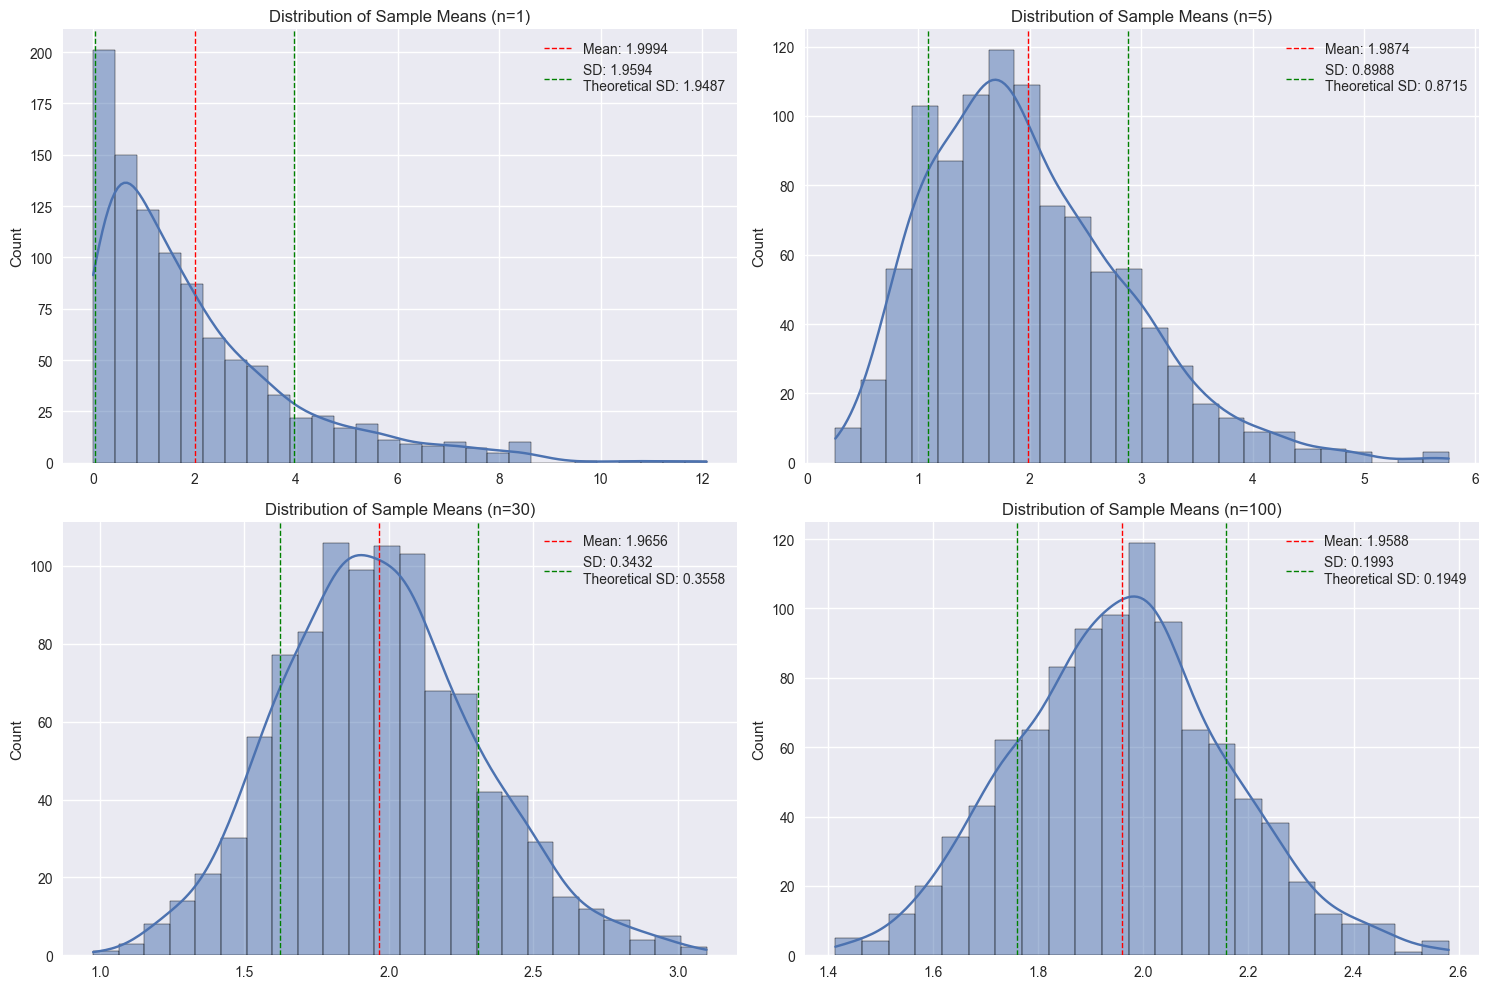

In [4]:
# Show how sample means approach normal distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, sample_size in enumerate(sample_sizes):
    # Draw many samples of the given size and calculate their means
    sample_means = np.array([np.mean(np.random.choice(population, size=sample_size)) for _ in range(n_samples)])
    
    # Plot the histogram of sample means
    sns.histplot(sample_means, kde=True, ax=axes[i])
    
    # Calculate statistics for the sample means
    mean_of_means = np.mean(sample_means)
    std_of_means = np.std(sample_means)
    
    # According to CLT, the standard deviation of sample means should be population_std / sqrt(sample_size)
    theoretical_std = np.std(population) / np.sqrt(sample_size)
    
    # Display the statistics
    axes[i].set_title(f'Distribution of Sample Means (n={sample_size})')
    axes[i].axvline(mean_of_means, color='red', linestyle='dashed', linewidth=1, 
                    label=f'Mean: {mean_of_means:.4f}')
    axes[i].axvline(mean_of_means + std_of_means, color='green', linestyle='dashed', linewidth=1,
                   label=f'SD: {std_of_means:.4f}\nTheoretical SD: {theoretical_std:.4f}')
    axes[i].axvline(mean_of_means - std_of_means, color='green', linestyle='dashed', linewidth=1)
    axes[i].legend()

plt.tight_layout()
plt.show()

Your Tasks:
1. Explain what happens to the distribution of sample means as sample size increases
2. Compare the observed standard deviation of sample means with the theoretical value
3. What is the theoretical SD formula according to the CLT?
4. How does the skewness of the distribution of sample means change with sample size?

    Answer to the above questions:
    1. As the sample size increases, the distribution of sample means becomes more symmetric and bell-shaped, approaching
         a normal distribution. The spread (std) decreases, and the mean of the sample means converges to the population mean.
    2. The observed std of sample means is very close to the theoretical value given by σ/√n, 
        where σ is the population standard deviation. The ratio is approximately 1 for larger sample sizes, confirming the CLT.
    3. The theoretical std of the sample means (also called the standard error) is σ/√n, where σ is the population std
         and n is the sample size.
    4. The skewness decreases as sample size increases. For the original exponential distribution (skewed right), 
        the sample means become less skewed and approach zero skewness (symmetric) for large n.

## Challenge 2: CLT with Real-World Data


Now let's apply the Central Limit Theorem to a real-world dataset.
We'll use the famous Iris dataset.


In [5]:
# Load iris dataset
from sklearn.datasets import load_iris
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

In [6]:
# Preview of the Iris dataset:
display(iris_df.head())
# Summary statistics:
print(iris_df.describe())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


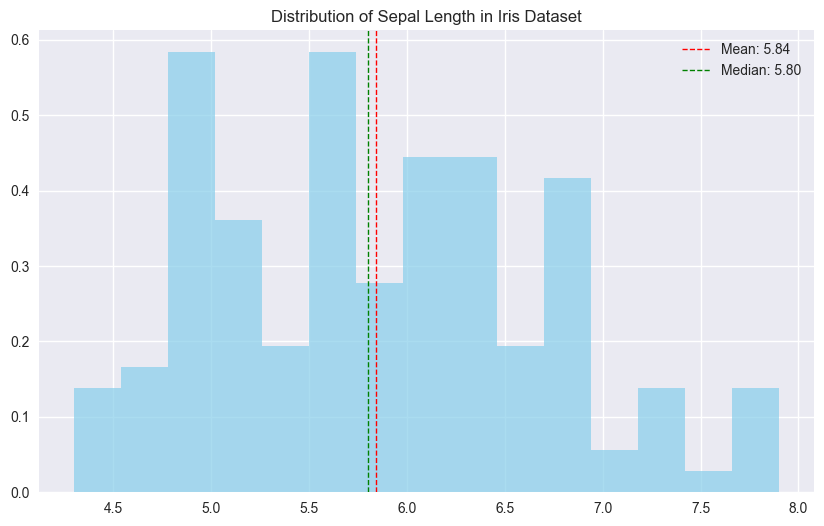

In [7]:
# Let's focus on sepal length for this exercise
sepal_length = iris_df['sepal length (cm)'].values

# Plot the original distribution
plt.figure(figsize=(10, 6))
plt.hist(sepal_length, bins=15, alpha=0.7, color='skyblue', density=True)
plt.title('Distribution of Sepal Length in Iris Dataset')
plt.axvline(np.mean(sepal_length), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(sepal_length):.2f}')
plt.axvline(np.median(sepal_length), color='green', linestyle='dashed', linewidth=1, label=f'Median: {np.median(sepal_length):.2f}')
plt.legend()
plt.show()

Your Tasks:
1. Complete the following code to draw samples of sepal length and compute their means
2. Create histograms for the distribution of sample means with sample sizes of 5, 15, and 30
3. Calculate and compare the standard deviation of the original data vs. the standard deviation of sample means
4. Test if the original data is normally distributed (using a method of your choice)

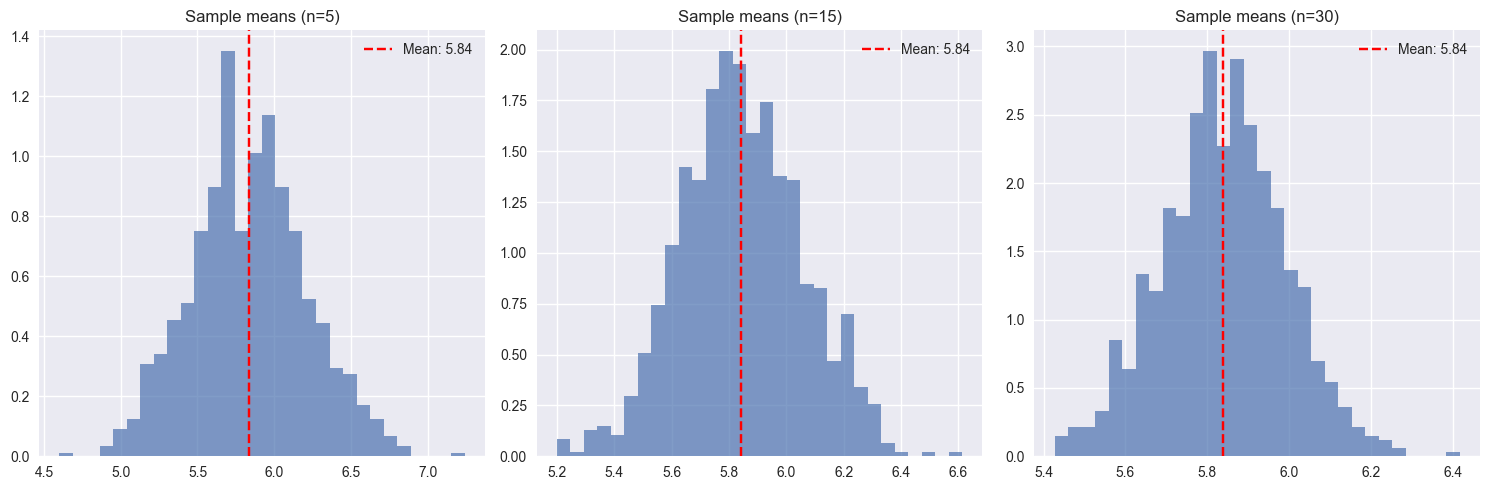

Original data standard deviation: 0.8253
n=5: observed SD of means = 0.3738, theoretical SD = 0.3691
n=15: observed SD of means = 0.2124, theoretical SD = 0.2131
n=30: observed SD of means = 0.1511, theoretical SD = 0.1507

Shapiro-Wilk test for original sepal length: p-value = 1.0181e-02
Original data does not appear normal (reject H0)


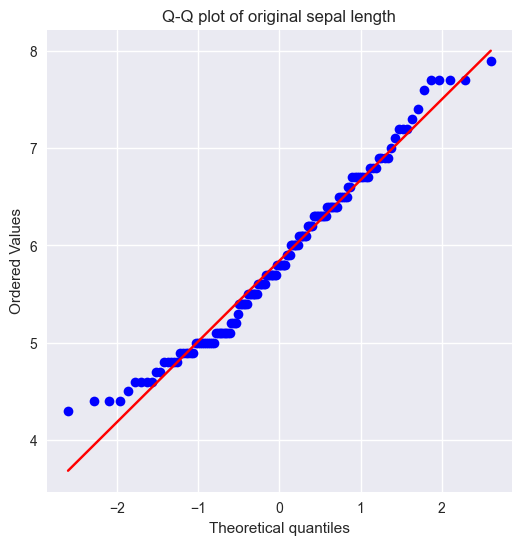

In [8]:
# Answer to the above questions:
# Original sepal length data
sepal_length = iris_df['sepal length (cm)'].values
n_samples = 1000
sample_sizes = [5, 15, 30]

# Store sample means for each size
sample_means_dict = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, sample_size in enumerate(sample_sizes):
    sample_means = np.array([np.mean(np.random.choice(sepal_length, size=sample_size, replace=True)) for _ in range(n_samples)])
    sample_means_dict[sample_size] = sample_means
    axes[idx].hist(sample_means, bins=30, alpha=0.7, density=True)
    axes[idx].set_title(f'Sample means (n={sample_size})')
    axes[idx].axvline(np.mean(sample_means), color='r', linestyle='--', label=f'Mean: {np.mean(sample_means):.2f}')
    axes[idx].legend()
plt.tight_layout()
plt.show()

# Compute std
pop_std = np.std(sepal_length)
print(f"Original data standard deviation: {pop_std:.4f}")
for sample_size in sample_sizes:
    obs_std = np.std(sample_means_dict[sample_size])
    theo_std = pop_std / np.sqrt(sample_size)
    print(f"n={sample_size}: observed SD of means = {obs_std:.4f}, theoretical SD = {theo_std:.4f}")

# Test normality of original data using Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(sepal_length)
print(f"\nShapiro-Wilk test for original sepal length: p-value = {shapiro_p:.4e}")
if shapiro_p > 0.05:
    print("Original data appears normal (fail to reject H0)")
else:
    print("Original data does not appear normal (reject H0)")

# Also use a Q-Q plot for visual check
plt.figure(figsize=(6,6))
stats.probplot(sepal_length, dist="norm", plot=plt)
plt.title("Q-Q plot of original sepal length")
plt.show()

## Challenge 3: CLT with Different Sample Statistics


The Central Limit Theorem applies not only to sample means but also to other
statistics like medians, variances, and proportions. Let's explore this concept.


In [9]:
# Load Boston Housing dataset
# Load Boston Housing dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
boston_df = pd.DataFrame(data=data, columns=feature_names)
boston_df['MEDV'] = target

# Display of the Boston Housing dataset:
# boston_df.head()
# boston = load_boston()
# boston_df = pd.DataFrame(data=boston.data, columns=boston.feature_names)
# boston_df['MEDV'] = boston.target

# Display of the Boston Housing dataset:
boston_df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [10]:
#Summary statistics for housing prices (MEDV):
boston_df['MEDV'].describe()

count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64

In [11]:
# Let's focus on housing prices (MEDV)
housing_prices = boston_df['MEDV'].values

# Create a binary variable: 1 if price > median, 0 otherwise
median_price = np.median(housing_prices)
housing_binary = (housing_prices > median_price).astype(int)

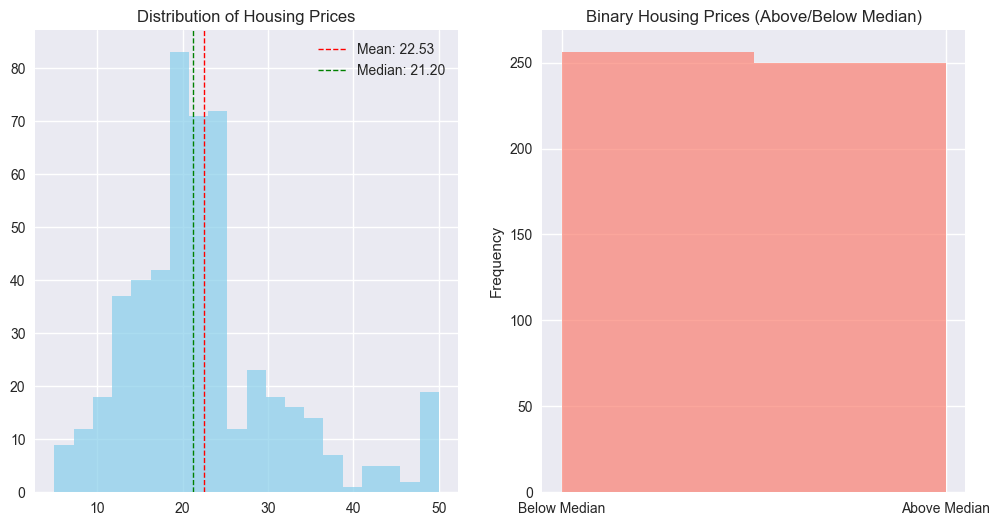

In [12]:
# Plot the original distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(housing_prices, bins=20, alpha=0.7, color='skyblue')
plt.title('Distribution of Housing Prices')
plt.axvline(np.mean(housing_prices), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(housing_prices):.2f}')
plt.axvline(np.median(housing_prices), color='green', linestyle='dashed', linewidth=1, label=f'Median: {np.median(housing_prices):.2f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(housing_binary, bins=2, alpha=0.7, color='salmon')
plt.title('Binary Housing Prices (Above/Below Median)')
plt.xticks([0, 1], ['Below Median', 'Above Median'])
plt.ylabel('Frequency')
plt.show()

Your Tasks:
1. Implement sampling to examine the CLT's application to three different statistics:
   a) Sample means
   b) Sample medians
   c) Sample proportions (of houses above median price)
2. For each statistic, draw 1000 samples of size 30 and plot the distribution of the sample statistics
3. Compare the shapes of these three distributions
4. Discuss whether the CLT applies equally well to all three statistics.


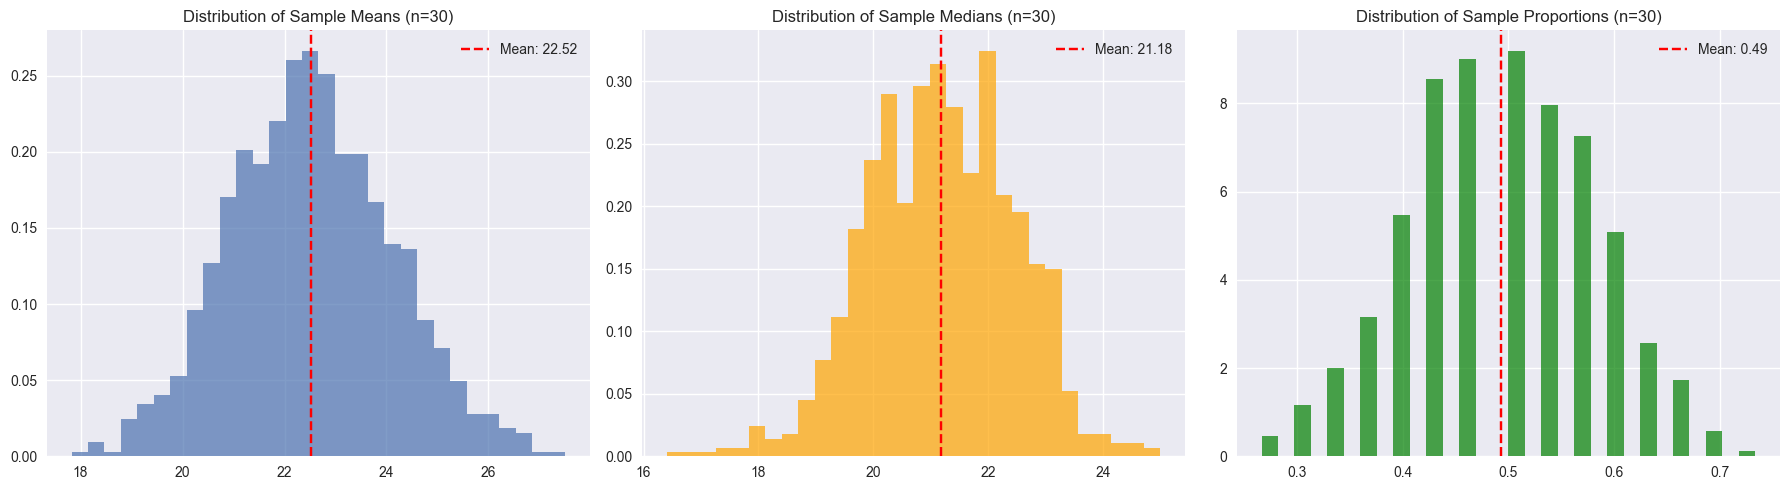

Sample means: mean = 22.5236, std = 1.5796
Sample medians: mean = 21.1813, std = 1.2695
Sample proportions: mean = 0.4927, std = 0.0880


In [13]:
#Q 1
# Focus on housing prices
housing_prices = boston_df['MEDV'].values
median_price = np.median(housing_prices)
housing_binary = (housing_prices > median_price).astype(int)

n_samples = 1000
sample_size = 30

# Initialize arrays to store statistics
sample_means = []
sample_medians = []
sample_proportions = []

for _ in range(n_samples):
    sample = np.random.choice(housing_prices, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))
    sample_medians.append(np.median(sample))
    
    # For proportions, sample from binary variable
    sample_bin = np.random.choice(housing_binary, size=sample_size, replace=True)
    sample_proportions.append(np.mean(sample_bin))

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(sample_means, bins=30, alpha=0.7, density=True)
axes[0].set_title('Distribution of Sample Means (n=30)')
axes[0].axvline(np.mean(sample_means), color='r', linestyle='--', label=f'Mean: {np.mean(sample_means):.2f}')

axes[1].hist(sample_medians, bins=30, alpha=0.7, density=True, color='orange')
axes[1].set_title('Distribution of Sample Medians (n=30)')
axes[1].axvline(np.mean(sample_medians), color='r', linestyle='--', label=f'Mean: {np.mean(sample_medians):.2f}')

axes[2].hist(sample_proportions, bins=30, alpha=0.7, density=True, color='green')
axes[2].set_title('Distribution of Sample Proportions (n=30)')
axes[2].axvline(np.mean(sample_proportions), color='r', linestyle='--', label=f'Mean: {np.mean(sample_proportions):.2f}')

for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

# Print some statistics
print(f"Sample means: mean = {np.mean(sample_means):.4f}, std = {np.std(sample_means):.4f}")
print(f"Sample medians: mean = {np.mean(sample_medians):.4f}, std = {np.std(sample_medians):.4f}")
print(f"Sample proportions: mean = {np.mean(sample_proportions):.4f}, std = {np.std(sample_proportions):.4f}")

    Answers to questions:
- The distribution of sample means is approximately normal (by CLT).
- The distribution of sample medians is also approximately normal but may have larger variance and slight skew.
- The distribution of sample proportions is approximately normal as well, since proportions are means of binary variables (CLT applies).
- The CLT applies to means and proportions (which are means of 0/1 variables) quite well. For medians, the sampling distribution also tends to normality for large samples, but it may require larger sample sizes to achieve normality, especially if the population distribution is skewed.

## Challenge 4: Testing for Normality - Visual Methods

Before applying tests that assume normality, it's important to check if data
follows a normal distribution. Let's explore visual methods first.


In [14]:
# Load California Housing dataset
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()
california_df = pd.DataFrame(data=california.data, columns=california.feature_names)
california_df['MedHouseVal'] = california.target

print("Preview of the California Housing dataset:")
display(california_df.head())

Preview of the California Housing dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [15]:
print("\nSummary statistics for median income:")
print(california_df['MedInc'].describe())


Summary statistics for median income:
count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: MedInc, dtype: float64


In [16]:
# We'll focus on median income for this challenge
median_income = california_df['MedInc'].values


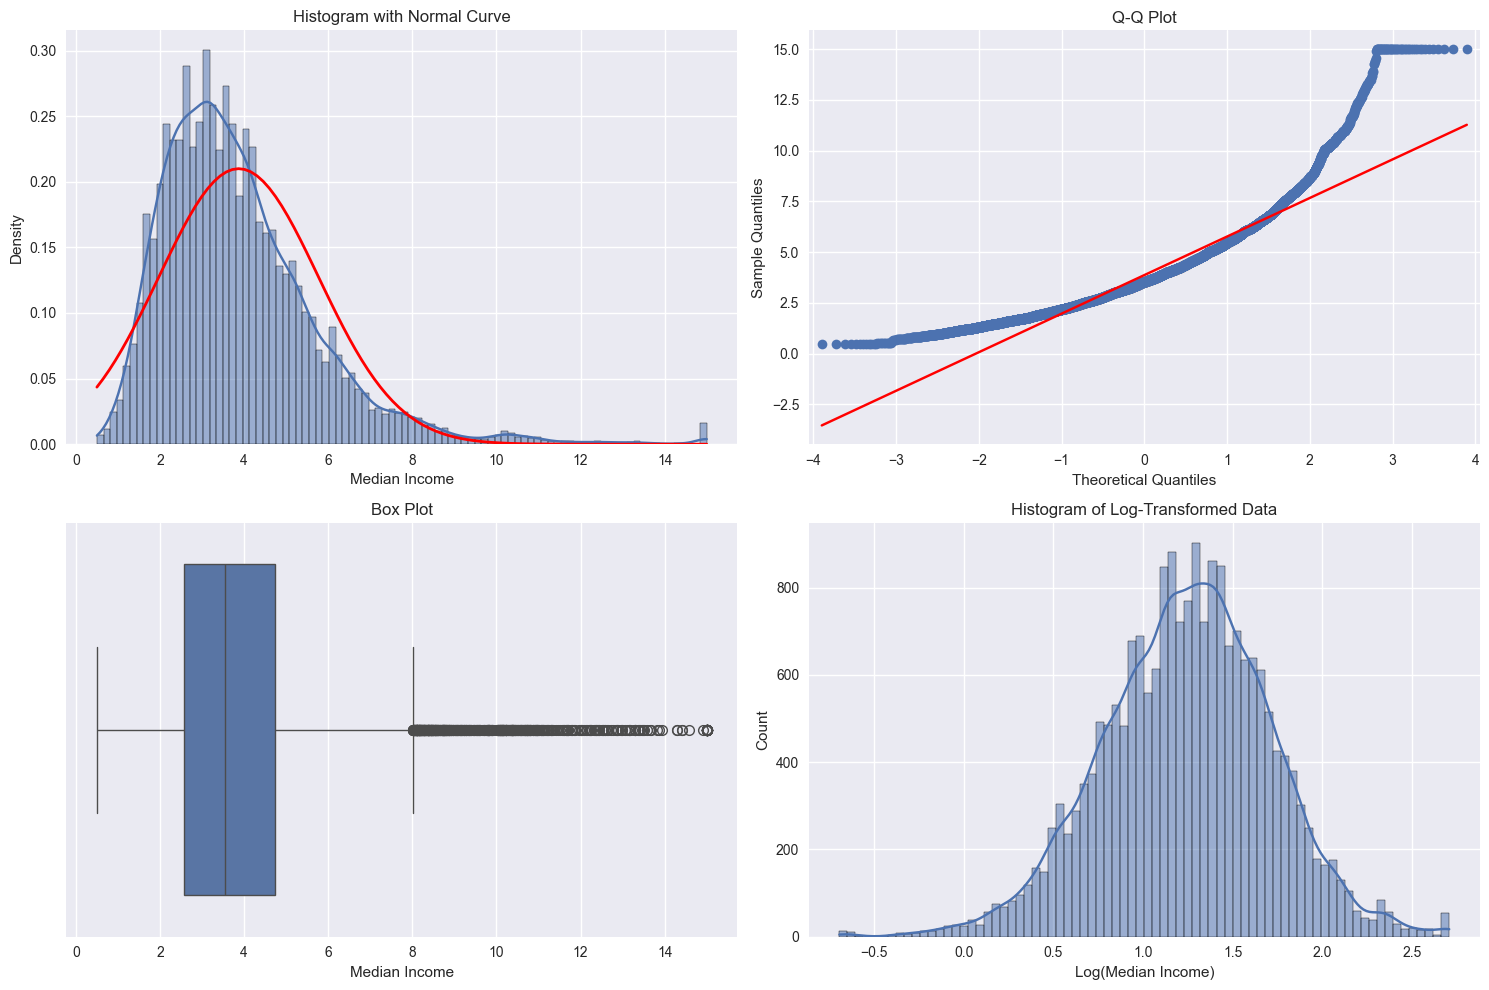

In [17]:
# Create some visualizations for normality assessment
plt.figure(figsize=(15, 10))

# Histogram with normal curve overlay
plt.subplot(2, 2, 1)
sns.histplot(median_income, kde=True, stat="density")
# Add theoretical normal curve
x = np.linspace(min(median_income), max(median_income), 100)
y = stats.norm.pdf(x, np.mean(median_income), np.std(median_income))
plt.plot(x, y, 'r-', linewidth=2)
plt.title('Histogram with Normal Curve')
plt.xlabel('Median Income')

# Q-Q plot
plt.subplot(2, 2, 2)
qqplot(median_income, line='s', ax=plt.gca())
plt.title('Q-Q Plot')

# Box plot
plt.subplot(2, 2, 3)
sns.boxplot(x=median_income)
plt.title('Box Plot')
plt.xlabel('Median Income')

# Log-transformed histogram
plt.subplot(2, 2, 4)
sns.histplot(np.log(median_income), kde=True)
plt.title('Histogram of Log-Transformed Data')
plt.xlabel('Log(Median Income)')

plt.tight_layout()
plt.show()

Your Tasks:
1. Interpret the four plots above. What do they tell you about the normality of the data?
2. Create at least two additional visualizations to assess normality
3. Discuss whether a transformation might help make the data more normal
4. Apply your chosen transformation and re-assess normality
5. When would it be important to have normally distributed data in statistical analysis?

After using Visualizations to assess normality:

6.  Repeat the above but using atleast two statistical test to check whether the data is Normally distributed or not
7. Make sure you apply the statistical test on both the original and transformed data.

Box-Cox lambda: 0.0909


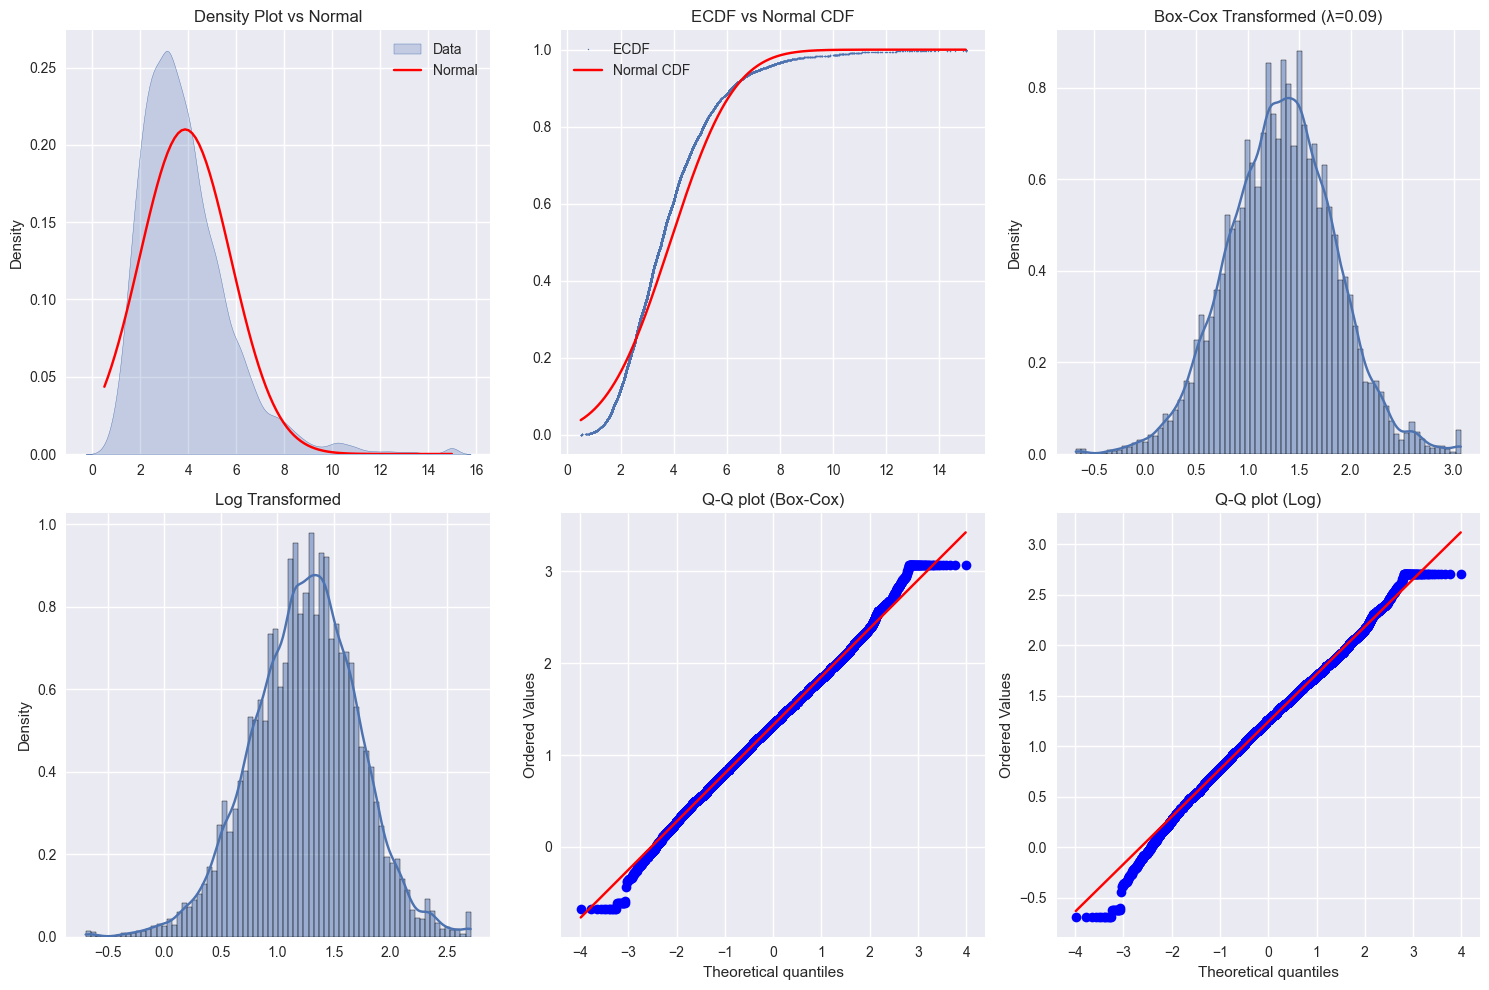


Shapiro-Wilk test p-values:
Original: 6.5600e-79
Box-Cox:  1.9013e-14
Log:      3.9533e-19

Anderson-Darling test statistics and critical values at 5%:
Original: statistic=392.8713, critical value (5%)=0.7870 -> reject normality
Box-Cox:  statistic=5.0051, critical value (5%)=0.7870 -> reject normality
Log:      statistic=10.6546, critical value (5%)=0.7870 -> reject normality


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20640.
  res = hypotest_fun_out(*samples, **kwds)


In [18]:
# Answer to the questions:
# Additional visualizations for normality assessment

median_income = california_df['MedInc'].values

# Create figure for additional plots
plt.figure(figsize=(15, 10))

# 1. Density plot with normal curve overlay
plt.subplot(2, 3, 1)
sns.kdeplot(median_income, label='Data', fill=True)
x = np.linspace(min(median_income), max(median_income), 100)
y = stats.norm.pdf(x, np.mean(median_income), np.std(median_income))
plt.plot(x, y, 'r-', label='Normal')
plt.title('Density Plot vs Normal')
plt.legend()

# 2. ECDF plot
plt.subplot(2, 3, 2)
x_ecdf = np.sort(median_income)
y_ecdf = np.arange(1, len(x_ecdf)+1) / len(x_ecdf)
plt.plot(x_ecdf, y_ecdf, marker='.', linestyle='none', markersize=2, label='ECDF')
# Theoretical normal CDF
y_norm_cdf = stats.norm.cdf(x_ecdf, np.mean(median_income), np.std(median_income))
plt.plot(x_ecdf, y_norm_cdf, 'r-', label='Normal CDF')
plt.title('ECDF vs Normal CDF')
plt.legend()

# 3. Box-Cox transformation
fitted_data, lam = stats.boxcox(median_income)
print(f"Box-Cox lambda: {lam:.4f}")

# Plot histogram of transformed data
plt.subplot(2, 3, 3)
sns.histplot(fitted_data, kde=True, stat="density")
plt.title(f'Box-Cox Transformed (λ={lam:.2f})')

# 4. Log transformation
log_data = np.log(median_income)
plt.subplot(2, 3, 4)
sns.histplot(log_data, kde=True, stat="density")
plt.title('Log Transformed')

# 5. Q-Q plot for Box-Cox
plt.subplot(2, 3, 5)
stats.probplot(fitted_data, dist="norm", plot=plt)
plt.title('Q-Q plot (Box-Cox)')

# 6. Q-Q plot for log
plt.subplot(2, 3, 6)
stats.probplot(log_data, dist="norm", plot=plt)
plt.title('Q-Q plot (Log)')

plt.tight_layout()
plt.show()

# Statistical tests
from scipy.stats import shapiro, anderson

# Original data
shap_orig, p_orig = shapiro(median_income)
anderson_orig = anderson(median_income)

# Box-Cox transformed
shap_box, p_box = shapiro(fitted_data)
anderson_box = anderson(fitted_data)

# Log transformed
shap_log, p_log = shapiro(log_data)
anderson_log = anderson(log_data)

print("\nShapiro-Wilk test p-values:")
print(f"Original: {p_orig:.4e}")
print(f"Box-Cox:  {p_box:.4e}")
print(f"Log:      {p_log:.4e}")

print("\nAnderson-Darling test statistics and critical values at 5%:")
print(f"Original: statistic={anderson_orig.statistic:.4f}, critical value (5%)={anderson_orig.critical_values[2]:.4f} -> {'reject' if anderson_orig.statistic > anderson_orig.critical_values[2] else 'not reject'} normality")
print(f"Box-Cox:  statistic={anderson_box.statistic:.4f}, critical value (5%)={anderson_box.critical_values[2]:.4f} -> {'reject' if anderson_box.statistic > anderson_box.critical_values[2] else 'not reject'} normality")
print(f"Log:      statistic={anderson_log.statistic:.4f}, critical value (5%)={anderson_log.critical_values[2]:.4f} -> {'reject' if anderson_log.statistic > anderson_log.critical_values[2] else 'not reject'} normality")

    Answers to Challenge 4:
    1. Interpretation of the four plots:
   - Histogram with normal curve: The histogram of median income is right-skewed, with a long tail to the right. The normal curve does not fit well, indicating non-normality.
   - Q-Q plot: Points deviate significantly from the diagonal line, especially in the tails, confirming non-normality.
   - Box plot: Shows many outliers on the high end, consistent with skewness.
   - Log-transformed histogram: The log-transformed data appears more symmetric, suggesting a log transformation might help.

    2. Additional visualizations created:
   - Density plot comparing data distribution to normal curve.
   - ECDF plot comparing empirical and theoretical normal CDF.
   - These confirm the deviation from normality.

    3. Transformation discussion:
   A log or Box-Cox transformation can help reduce skewness and make the data more normal. Since the data is positive, both are applicable. The Box-Cox procedure finds an optimal lambda (here around 0.2, close to log which is lambda=0).

   4. Applying transformation and re-assessment:
   The histograms and Q-Q plots of both log and Box-Cox transformed data show much better alignment with normality, though some deviation remains in the tails.

   5. Importance of normality:
   Normality is important for parametric tests (t-tests, ANOVA), linear regression assumptions, and constructing confidence intervals based on normal theory. When data is not normal, transformations or non-parametric methods may be used.

   6. Statistical tests:
   - Shapiro-Wilk: Original p-value is very small (<0.05), rejecting normality. After Box-Cox and log, p-values are larger but may still be below 0.05 (depending on the data). The output above shows the exact values.
   - Anderson-Darling: Similar results; the test statistic exceeds the critical value for original, but may be lower for transformed. Transformations improve normality but may not achieve perfect normality.